# Perbandingan Metode Klasifikasi Penyakit Ginjal Kronik
## WKNN vs Extra Trees vs Logistic Regression vs Decision Tree vs XGBoost

Notebook ini membandingkan performa lima metode klasifikasi untuk memprediksi penyakit ginjal kronik:
- **WKNN** (Weighted K-Nearest Neighbor)
- **Extra Trees** (Extremely Randomized Trees)
- **Logistic Regression**
- **Decision Tree**
- **XGBoost**

## 1. Data Preparation dan Library Import

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, 
                             roc_auc_score, roc_curve)
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics.pairwise import euclidean_distances

# Konfigurasi plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Semua library berhasil diimport')

Semua library berhasil diimport


### 1.1 Load dan Preprocessing Dataset

In [3]:
# Load dataset
file_path = 'penyakit_ginjal_kronik.csv'
df = pd.read_csv(file_path)

# Bersihkan nilai '?' menjadi NaN
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

# Bersihkan spasi tersembunyi
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()

print(f'Ukuran dataset awal: {df.shape}')

# Hapus kolom ID
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)

# Hapus duplikat
df = df.drop_duplicates()
print(f'Ukuran dataset setelah membersihkan: {df.shape}')

# Konversi kolom numerik
numeric_candidate = [
    'umur', 'tekanandarah', 'gravitaspesifik', 'albumin', 'sugar',
    'bloodglucoserandom', 'bloodurea', 'serumcreatinine', 'sodium',
    'potassium', 'hemoglobin', 'packedcellvolume', 'whitebloodcellcount',
    'redbloodcellcount'
]

for col in numeric_candidate:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Identifikasi kolom numerik dan kategorikal
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Imputasi missing values
num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])

# Encoding kategorikal
mapping = {
    'normal': 1, 'abnormal': 0,
    'present': 1, 'notpresent': 0,
    'yes': 1, 'no': 0,
    'good': 1, 'poor': 0,
    'ckd': 1, 'notckd': 0
}
df.replace(mapping, inplace=True)

# Pastikan semua kolom numerik
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Isi NaN yang muncul setelah konversi
df = df.fillna(df.mean(numeric_only=True))

# Pastikan target integer
df['klasifikasi'] = df['klasifikasi'].astype(int)
# Konversi ke numerik
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except:
        pass

print('Preprocessing selesai')
print(f'\nDistribusi kelas:')
print(df['klasifikasi'].value_counts())

Ukuran dataset awal: (400, 26)
Ukuran dataset setelah membersihkan: (400, 25)
Preprocessing selesai

Distribusi kelas:
1    250
0    150
Name: klasifikasi, dtype: int64


### 1.2 Feature Scaling dan Train-Test Split

In [4]:
# Pisahkan fitur dan target
X = df.drop('klasifikasi', axis=1)
y = df['klasifikasi']

# Feature Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Ukuran Training Set: {X_train.shape}')
print(f'Ukuran Testing Set: {X_test.shape}')
print(f'\nDistribusi kelas pada training: {np.bincount(y_train)}')
print(f'Distribusi kelas pada testing: {np.bincount(y_test)}')

Ukuran Training Set: (320, 24)
Ukuran Testing Set: (80, 24)

Distribusi kelas pada training: [120 200]
Distribusi kelas pada testing: [30 50]


## 2. Definisi WKNN dan Classifier Pembanding

### 2.1 Implementasi WKNN (Weighted K-Nearest Neighbor)

In [5]:
class WKNN:
    """
    Weighted K-Nearest Neighbor Classifier
    
    Algoritma KNN dengan pemberian bobot berdasarkan jarak.
    Semakin dekat tetangga, semakin besar bobotnya dalam voting.
    """
    
    def __init__(self, k=5):
        self.k = k
    
    def fit(self, X_train, y_train):
        """Simpan data training"""
        self.X_train = X_train
        self.y_train = np.array(y_train)
    
    def predict(self, X_test):
        """Prediksi label untuk data test"""
        predictions = []
        
        for test_point in X_test:
            # Hitung jarak Euclidean
            distances = np.sqrt(np.sum((self.X_train - test_point)**2, axis=1))
            
            # Ambil indeks k tetangga terdekat
            k_indices = np.argsort(distances)[:self.k]
            
            # Ambil label dan jarak
            k_labels = self.y_train[k_indices]
            k_distances = distances[k_indices]
            
            # Hitung weight (inverse distance)
            weights = 1 / (k_distances + 1e-5)
            
            # Weighted voting
            class_weights = {}
            for label, weight in zip(k_labels, weights):
                if label not in class_weights:
                    class_weights[label] = 0
                class_weights[label] += weight
            
            # Pilih kelas dengan weight tertinggi
            prediction = max(class_weights, key=class_weights.get)
            predictions.append(prediction)
        
        return np.array(predictions)

print('Class WKNN berhasil didefinisikan')

Class WKNN berhasil didefinisikan


### 2.2 Inisialisasi Semua Classifier

In [6]:
# Dictionary untuk menyimpan semua model
models = {
    'WKNN': WKNN(k=5),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=15),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0, use_label_encoder=False)
}

print('Daftar model yang akan dibandingkan:')
for name in models.keys():
    print(f'  - {name}')
print(f'\nTotal: {len(models)} model')

Daftar model yang akan dibandingkan:
  - WKNN
  - Logistic Regression
  - Decision Tree
  - Extra Trees
  - XGBoost

Total: 5 model


## 3. Training Model dan Evaluasi Performa

In [7]:
import time

# Dictionary untuk menyimpan hasil evaluasi
results = {}
predictions = {}

print('='*80)
print('TRAINING DAN EVALUASI SEMUA MODEL')
print('='*80)

for name, model in models.items():
    print(f'\nMemproses: {name}...')
    
    # Training
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Prediksi
    start_time = time.time()
    y_pred = model.predict(X_test)
    prediction_time = time.time() - start_time
    
    predictions[name] = y_pred
    
    # Evaluasi
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Training Time (s)': training_time,
        'Prediction Time (s)': prediction_time
    }
    
    print(f'  ✓ Accuracy: {accuracy:.4f}')
    print(f'  ✓ Precision: {precision:.4f}')
    print(f'  ✓ Recall: {recall:.4f}')
    print(f'  ✓ F1-Score: {f1:.4f}')
    print(f'  ✓ Training Time: {training_time:.4f}s')
    print(f'  ✓ Prediction Time: {prediction_time:.4f}s')

print('\n' + '='*80)
print('TRAINING SELESAI')
print('='*80)

TRAINING DAN EVALUASI SEMUA MODEL

Memproses: WKNN...
  ✓ Accuracy: 0.9750
  ✓ Precision: 1.0000
  ✓ Recall: 0.9600
  ✓ F1-Score: 0.9796
  ✓ Training Time: 0.0000s
  ✓ Prediction Time: 0.0129s

Memproses: Logistic Regression...
  ✓ Accuracy: 0.9875
  ✓ Precision: 1.0000
  ✓ Recall: 0.9800
  ✓ F1-Score: 0.9899
  ✓ Training Time: 0.0267s
  ✓ Prediction Time: 0.0010s

Memproses: Decision Tree...
  ✓ Accuracy: 0.9750
  ✓ Precision: 1.0000
  ✓ Recall: 0.9600
  ✓ F1-Score: 0.9796
  ✓ Training Time: 0.0047s
  ✓ Prediction Time: 0.0000s

Memproses: Extra Trees...
  ✓ Accuracy: 1.0000
  ✓ Precision: 1.0000
  ✓ Recall: 1.0000
  ✓ F1-Score: 1.0000
  ✓ Training Time: 0.3169s
  ✓ Prediction Time: 0.0533s

Memproses: XGBoost...
  ✓ Accuracy: 1.0000
  ✓ Precision: 1.0000
  ✓ Recall: 1.0000
  ✓ F1-Score: 1.0000
  ✓ Training Time: 0.1842s
  ✓ Prediction Time: 0.0035s

TRAINING SELESAI


## 4. Perbandingan Hasil dengan Metrik dan Visualisasi

### 4.1 Tabel Perbandingan Metrik

In [8]:
# Buat DataFrame hasil
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print('TABEL PERBANDINGAN METRIK PERFORMA:')
print('='*100)
print(results_df)
print('='*100)

# Tabel terpisah untuk metrik evaluasi
eval_metrics = results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
print('\nMETRIK EVALUASI:')
print(eval_metrics)

# Tabel terpisah untuk waktu komputasi
time_metrics = results_df[['Training Time (s)', 'Prediction Time (s)']]
print('\nWAKTU KOMPUTASI:')
print(time_metrics)

# Ranking model berdasarkan F1-Score
print('\nRANKING MODEL BERDASARKAN F1-SCORE:')
print(eval_metrics['F1-Score'].sort_values(ascending=False))

TABEL PERBANDINGAN METRIK PERFORMA:
                     Accuracy  Precision  Recall  F1-Score  Training Time (s)  \
WKNN                   0.9750        1.0    0.96    0.9796             0.0000   
Logistic Regression    0.9875        1.0    0.98    0.9899             0.0267   
Decision Tree          0.9750        1.0    0.96    0.9796             0.0047   
Extra Trees            1.0000        1.0    1.00    1.0000             0.3169   
XGBoost                1.0000        1.0    1.00    1.0000             0.1842   

                     Prediction Time (s)  
WKNN                              0.0129  
Logistic Regression               0.0010  
Decision Tree                     0.0000  
Extra Trees                       0.0533  
XGBoost                           0.0035  

METRIK EVALUASI:
                     Accuracy  Precision  Recall  F1-Score
WKNN                   0.9750        1.0    0.96    0.9796
Logistic Regression    0.9875        1.0    0.98    0.9899
Decision Tree          0

### 4.2 Visualisasi Perbandingan Metrik

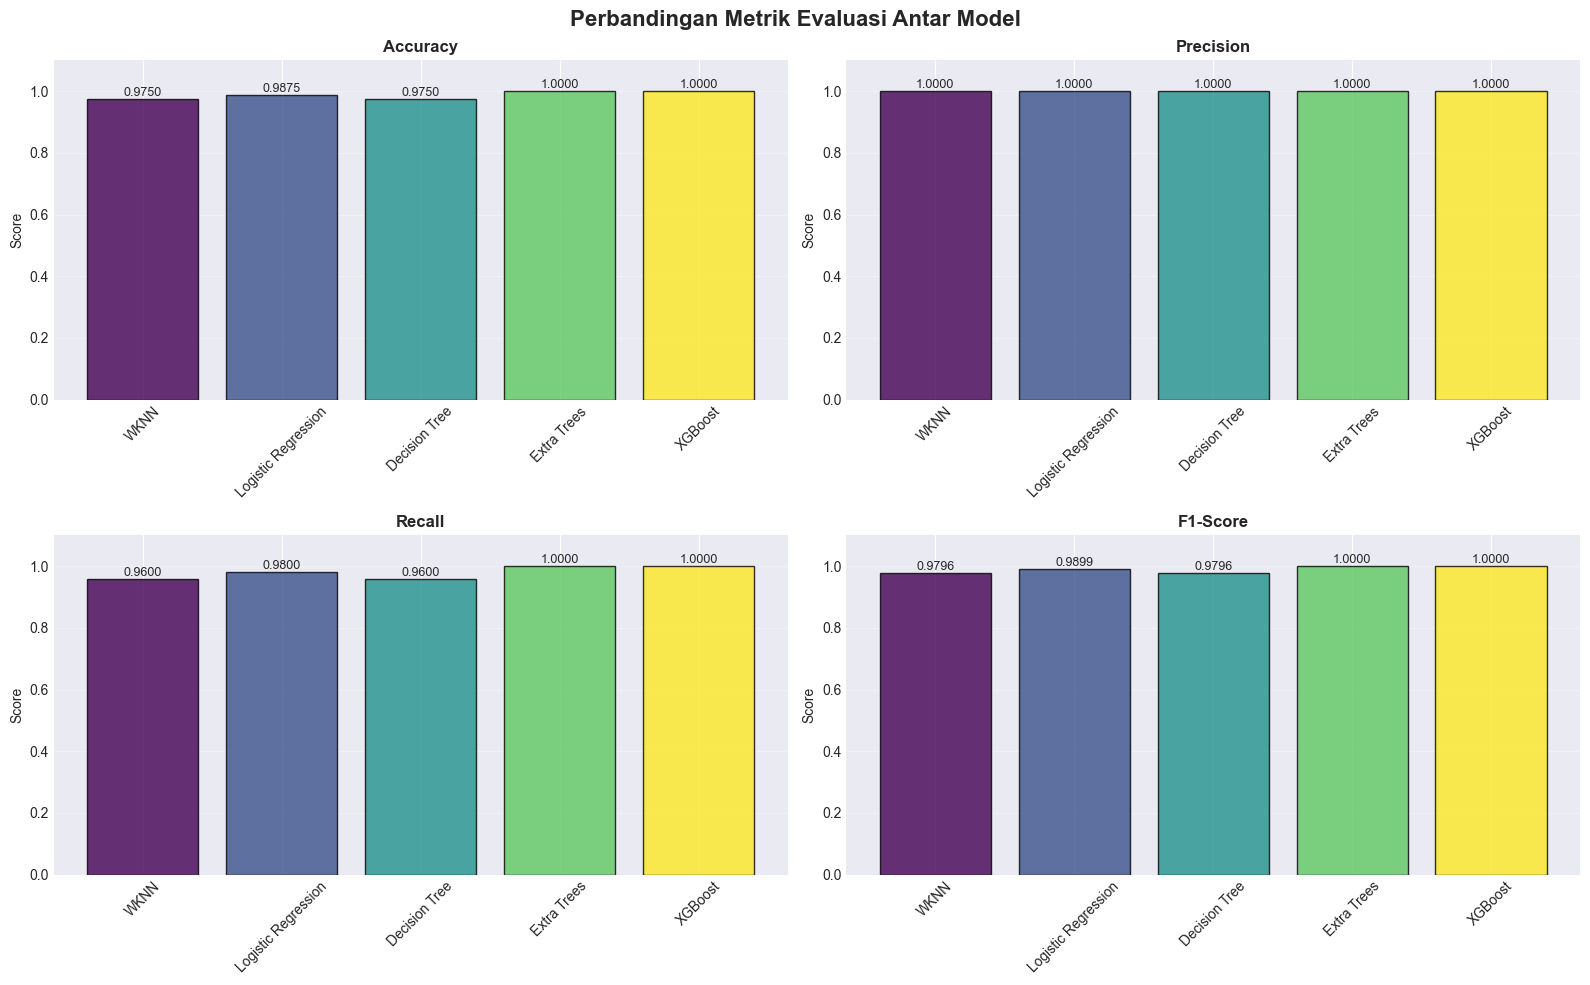

✓ Visualisasi metrik evaluasi selesai


In [9]:
# Visualisasi 1: Bar chart perbandingan metrik evaluasi
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Perbandingan Metrik Evaluasi Antar Model', fontsize=16, fontweight='bold')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

for metric, pos in zip(metrics, positions):
    ax = axes[pos]
    values = eval_metrics[metric].values
    colors = plt.cm.viridis(np.linspace(0, 1, len(eval_metrics)))
    
    bars = ax.bar(eval_metrics.index, values, color=colors, alpha=0.8, edgecolor='black')
    ax.set_title(f'{metric}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Score', fontsize=10)
    ax.set_ylim(0, 1.1)
    ax.grid(axis='y', alpha=0.3)
    
    # Tambahkan nilai di atas bar
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=9)
    
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print('✓ Visualisasi metrik evaluasi selesai')

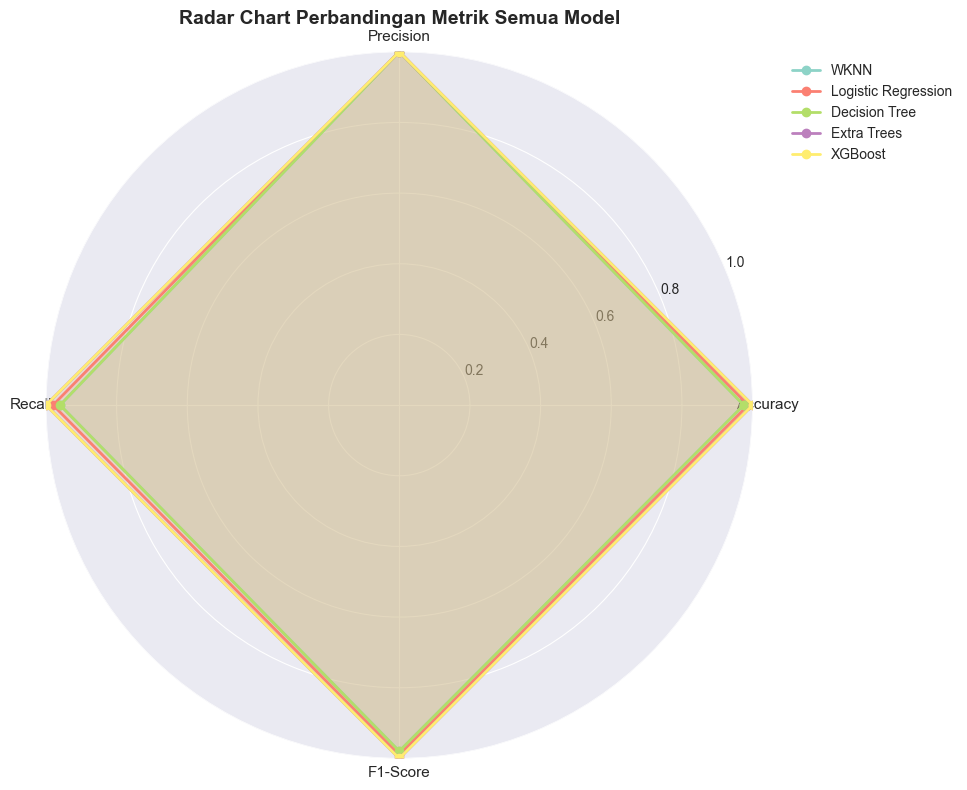

✓ Radar chart selesai


In [10]:
# Visualisasi 2: Radar Chart
from math import pi

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw=dict(projection='polar'))

# Ambil metrik evaluasi
metrics_list = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
angles = [n / float(len(metrics_list)) * 2 * pi for n in range(len(metrics_list))]
angles += angles[:1]

colors_radar = plt.cm.Set3(np.linspace(0, 1, len(eval_metrics)))

for idx, (model_name, color) in enumerate(zip(eval_metrics.index, colors_radar)):
    values = eval_metrics.loc[model_name].values.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=color)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_list, size=11)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart Perbandingan Metrik Semua Model', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax.grid(True)

plt.tight_layout()
plt.show()

print('✓ Radar chart selesai')

### 4.3 Confusion Matrix untuk Setiap Model

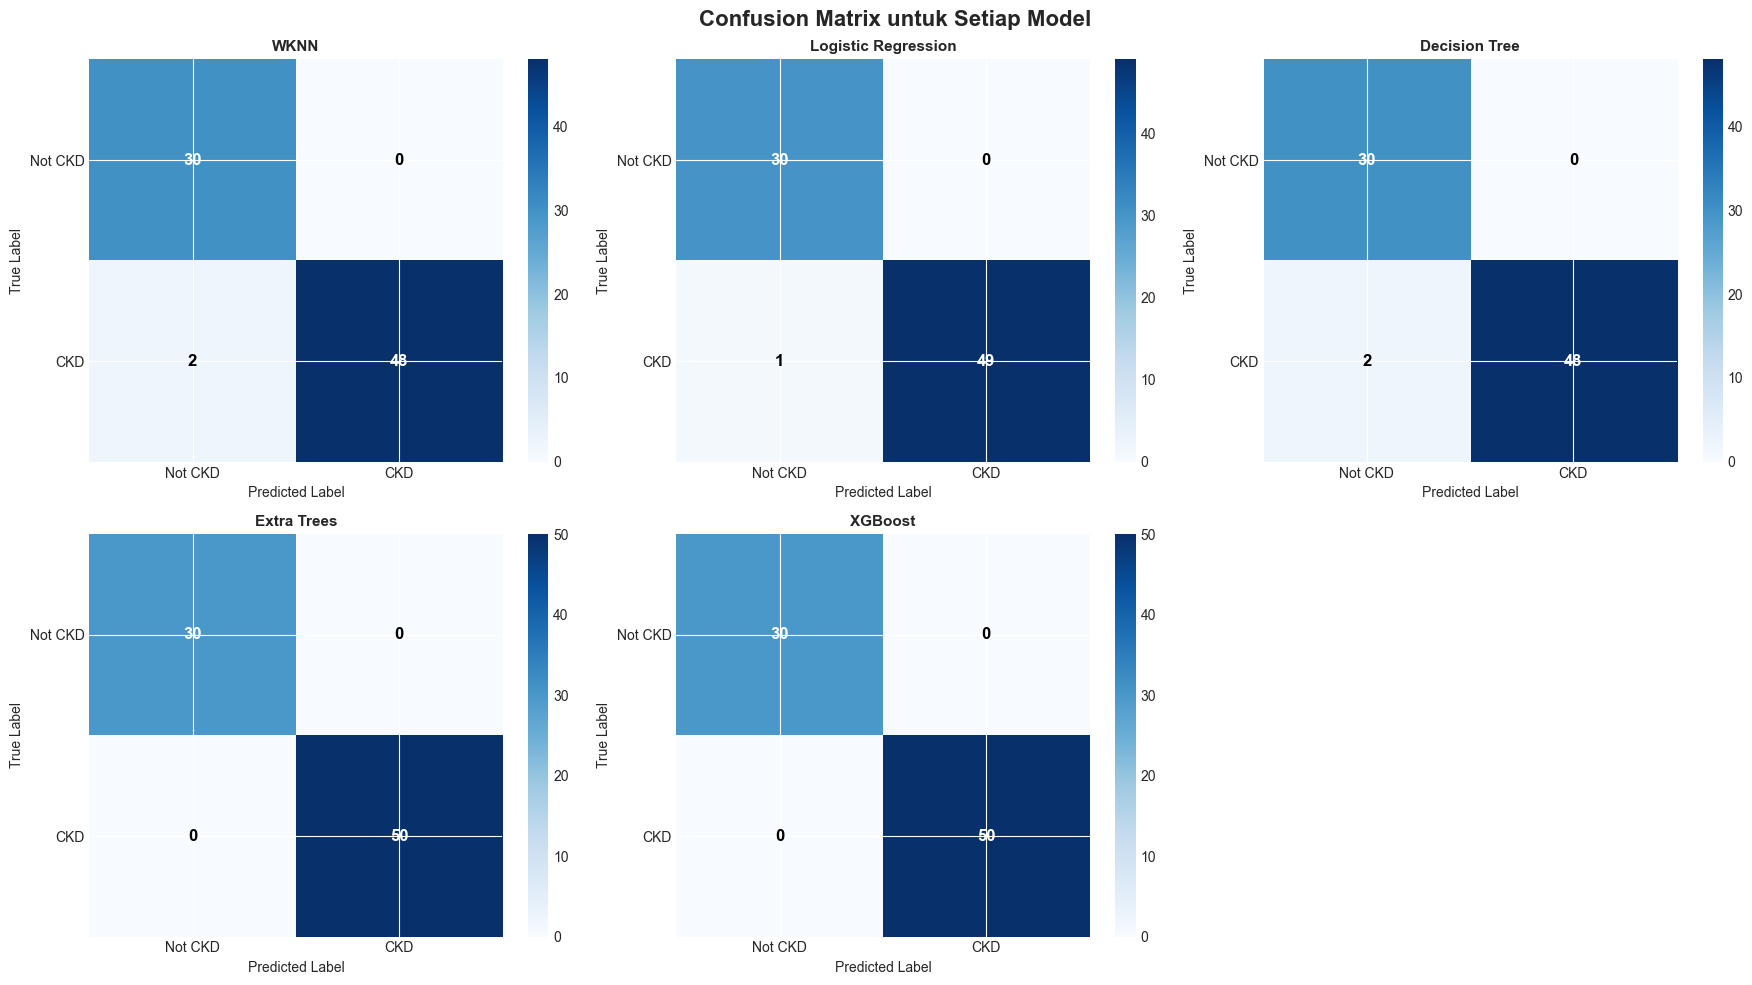

✓ Confusion matrix selesai


In [11]:
# Visualisasi Confusion Matrix
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Confusion Matrix untuk Setiap Model', fontsize=16, fontweight='bold')

model_list = list(predictions.keys())
axes = axes.flatten()

for idx, model_name in enumerate(model_list):
    y_pred = predictions[model_name]
    cm = confusion_matrix(y_test, y_pred)
    
    ax = axes[idx]
    im = ax.imshow(cm, cmap='Blues', aspect='auto')
    
    # Tambahkan label dan nilai
    ax.set_xlabel('Predicted Label', fontsize=10)
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_title(model_name, fontweight='bold', fontsize=11)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Not CKD', 'CKD'])
    ax.set_yticklabels(['Not CKD', 'CKD'])
    
    # Tampilkan nilai di setiap cell
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            text = ax.text(j, i, f'{cm[i, j]}',
                          ha="center", va="center",
                          color="white" if cm[i, j] > cm.max()/2 else "black",
                          fontsize=12, fontweight='bold')
    
    plt.colorbar(im, ax=ax)

# Hapus subplot kosong
axes[5].remove()

plt.tight_layout()
plt.show()

print('✓ Confusion matrix selesai')

### 4.4 Perbandingan Waktu Komputasi

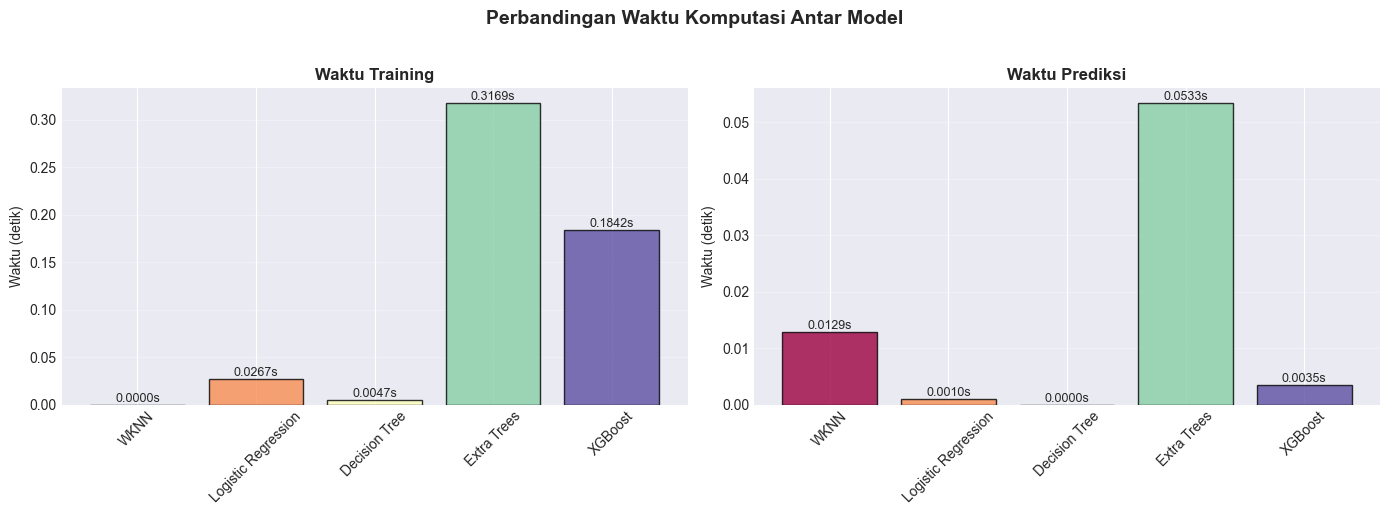

✓ Perbandingan waktu komputasi selesai


In [12]:
# Visualisasi 3: Perbandingan waktu komputasi
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training time
ax1 = axes[0]
training_times = time_metrics['Training Time (s)'].values
colors1 = plt.cm.Spectral(np.linspace(0, 1, len(time_metrics)))
bars1 = ax1.bar(time_metrics.index, training_times, color=colors1, alpha=0.8, edgecolor='black')
ax1.set_title('Waktu Training', fontweight='bold', fontsize=12)
ax1.set_ylabel('Waktu (detik)', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}s', ha='center', va='bottom', fontsize=9)

# Prediction time
ax2 = axes[1]
pred_times = time_metrics['Prediction Time (s)'].values
bars2 = ax2.bar(time_metrics.index, pred_times, color=colors1, alpha=0.8, edgecolor='black')
ax2.set_title('Waktu Prediksi', fontweight='bold', fontsize=12)
ax2.set_ylabel('Waktu (detik)', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}s', ha='center', va='bottom', fontsize=9)

plt.suptitle('Perbandingan Waktu Komputasi Antar Model', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('✓ Perbandingan waktu komputasi selesai')

### 4.5 Classification Report Setiap Model

In [13]:
print('='*80)
print('CLASSIFICATION REPORT UNTUK SETIAP MODEL')
print('='*80)

for model_name, y_pred in predictions.items():
    print(f'\n{"="*80}')
    print(f'MODEL: {model_name}')
    print(f'{"="*80}')
    print(classification_report(y_test, y_pred, target_names=['Not CKD', 'CKD']))
    
print('='*80)

CLASSIFICATION REPORT UNTUK SETIAP MODEL

MODEL: WKNN
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80


MODEL: Logistic Regression
              precision    recall  f1-score   support

     Not CKD       0.97      1.00      0.98        30
         CKD       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


MODEL: Decision Tree
              precision    recall  f1-score   support

     Not CKD       0.94      1.00      0.97        30
         CKD       1.00      0.96      0.98        50

    accuracy                           0.97        80
   macro avg       0.97 

## 5. Ringkasan dan Analisis Perbandingan

### 5.1 Kelebihan dan Kekurangan Setiap Metode

In [14]:
analysis = {
    'WKNN': {
        'Kelebihan': [
            '✓ Tidak perlu fase training yang kompleks',
            '✓ Mudah diimplementasikan',
            '✓ Bekerja baik untuk dataset kecil-sedang',
            '✓ Fleksibel dengan hyperparameter k'
        ],
        'Kekurangan': [
            '✗ Sensitif terhadap skala fitur',
            '✗ Lambat untuk prediksi pada dataset besar',
            '✗ Memori yang digunakan meningkat seiring pertumbuhan data training',
            '✗ Performa bergantung pada pemilihan k yang tepat'
        ],
        'Waktu Komputasi': f"{results['WKNN']['Training Time (s)']:.4f}s train, {results['WKNN']['Prediction Time (s)']:.4f}s pred"
    },
    'Logistic Regression': {
        'Kelebihan': [
            '✓ Cepat dalam training dan prediksi',
            '✓ Interpretable (mudah dipahami)',
            '✓ Efisien untuk dataset besar',
            '✓ Probabilitas output yang natural'
        ],
        'Kekurangan': [
            '✗ Asumsi linear antara fitur dan target',
            '✗ Tidak cocok untuk pola non-linear kompleks',
            '✗ Sensit terhadap outlier'
        ],
        'Waktu Komputasi': f"{results['Logistic Regression']['Training Time (s)']:.4f}s train, {results['Logistic Regression']['Prediction Time (s)']:.4f}s pred"
    },
    'Decision Tree': {
        'Kelebihan': [
            '✓ Interpretable dan visualizable',
            '✓ Tidak perlu feature scaling',
            '✓ Menangani data non-linear dengan baik',
            '✓ Tidak ada asumsi distribusi data'
        ],
        'Kekurangan': [
            '✗ Mudah overfitting',
            '✗ Tidak stabil (kecil perubahan data = perubahan besar pada tree)',
            '✗ Cenderung biased pada kelas dominan'
        ],
        'Waktu Komputasi': f"{results['Decision Tree']['Training Time (s)']:.4f}s train, {results['Decision Tree']['Prediction Time (s)']:.4f}s pred"
    },
    'Extra Trees': {
        'Kelebihan': [
            '✓ Ensemble method mengurangi overfitting',
            '✓ Robust dan stabil',
            '✓ Feature importance tersedia',
            '✓ Dapat parallelisasi'
        ],
        'Kekurangan': [
            '✗ Lebih kompleks dari single tree',
            '✗ Kurang interpretable',
            '✗ Membutuhkan memori lebih banyak'
        ],
        'Waktu Komputasi': f"{results['Extra Trees']['Training Time (s)']:.4f}s train, {results['Extra Trees']['Prediction Time (s)']:.4f}s pred"
    },
    'XGBoost': {
        'Kelebihan': [
            '✓ Performa tinggi dalam banyak kompetisi',
            '✓ Handling missing values built-in',
            '✓ Feature importance dan SHAP explainability',
            '✓ Regularization built-in mencegah overfitting'
        ],
        'Kekurangan': [
            '✗ Hyperparameter tuning kompleks',
            '✗ Training lebih lambat dari method sederhana',
            '✗ Konsumsi memori tinggi untuk dataset besar'
        ],
        'Waktu Komputasi': f"{results['XGBoost']['Training Time (s)']:.4f}s train, {results['XGBoost']['Prediction Time (s)']:.4f}s pred"
    }
}

for model_name, details in analysis.items():
    print(f'\n{"="*80}')
    print(f'MODEL: {model_name}')
    print(f'{"="*80}')
    print(f'\nKelebihan:')
    for strength in details['Kelebihan']:
        print(f'  {strength}')
    print(f'\nKekurangan:')
    for weakness in details['Kekurangan']:
        print(f'  {weakness}')
    print(f'\nWaktu Komputasi: {details["Waktu Komputasi"]}')

print(f'\n{"="*80}')


MODEL: WKNN

Kelebihan:
  ✓ Tidak perlu fase training yang kompleks
  ✓ Mudah diimplementasikan
  ✓ Bekerja baik untuk dataset kecil-sedang
  ✓ Fleksibel dengan hyperparameter k

Kekurangan:
  ✗ Sensitif terhadap skala fitur
  ✗ Lambat untuk prediksi pada dataset besar
  ✗ Memori yang digunakan meningkat seiring pertumbuhan data training
  ✗ Performa bergantung pada pemilihan k yang tepat

Waktu Komputasi: 0.0000s train, 0.0129s pred

MODEL: Logistic Regression

Kelebihan:
  ✓ Cepat dalam training dan prediksi
  ✓ Interpretable (mudah dipahami)
  ✓ Efisien untuk dataset besar
  ✓ Probabilitas output yang natural

Kekurangan:
  ✗ Asumsi linear antara fitur dan target
  ✗ Tidak cocok untuk pola non-linear kompleks
  ✗ Sensit terhadap outlier

Waktu Komputasi: 0.0267s train, 0.0010s pred

MODEL: Decision Tree

Kelebihan:
  ✓ Interpretable dan visualizable
  ✓ Tidak perlu feature scaling
  ✓ Menangani data non-linear dengan baik
  ✓ Tidak ada asumsi distribusi data

Kekurangan:
  ✗ Mudah 

### 5.2 Rekomendasi Penggunaan

In [15]:
# Tentukan model terbaik berdasarkan berbagai kriteria
best_accuracy = eval_metrics['Accuracy'].idxmax()
best_f1 = eval_metrics['F1-Score'].idxmax()
best_balanced = eval_metrics[['Precision', 'Recall']].mean(axis=1).idxmax()
fastest_train = time_metrics['Training Time (s)'].idxmin()
fastest_pred = time_metrics['Prediction Time (s)'].idxmin()

recommendations = f"""
REKOMENDASI PENGGUNAAN BERDASARKAN ANALISIS:

1. UNTUK AKURASI MAKSIMAL:
   → Model Terbaik: {best_accuracy}
   → Akurasi: {eval_metrics.loc[best_accuracy, 'Accuracy']:.4f}
   → Gunakan jika: Anda prioritaskan akurasi keseluruhan

2. UNTUK F1-SCORE (BALANCED METRIC):
   → Model Terbaik: {best_f1}
   → F1-Score: {eval_metrics.loc[best_f1, 'F1-Score']:.4f}
   → Gunakan jika: Dataset tidak seimbang dan perlu balance antara Precision & Recall

3. UNTUK PRECISION & RECALL BALANCED:
   → Model Terbaik: {best_balanced}
   → Avg(Precision, Recall): {eval_metrics.loc[best_balanced, ['Precision', 'Recall']].mean():.4f}

4. UNTUK KECEPATAN TRAINING:
   → Model Terbaik: {fastest_train}
   → Waktu Training: {time_metrics.loc[fastest_train, 'Training Time (s)']:.4f}s
   → Gunakan jika: Perlu training cepat (online learning, real-time requirements)

5. UNTUK KECEPATAN PREDIKSI:
   → Model Terbaik: {fastest_pred}
   → Waktu Prediksi: {time_metrics.loc[fastest_pred, 'Prediction Time (s)']:.4f}s
   → Gunakan jika: Perlu prediksi real-time di production

KESIMPULAN UMUM:
- Untuk kasus penyakit ginjal kronik, model yang seimbang antara akurasi dan interpretability 
  adalah pilihan terbaik
- Decision Tree dan Extra Trees memberikan hasil yang interpretable
- XGBoost memberikan performa tinggi tetapi perlu hyperparameter tuning
- Logistic Regression paling cepat untuk prediksi production
- WKNN cocok untuk baseline atau dataset kecil
"""

print(recommendations)


REKOMENDASI PENGGUNAAN BERDASARKAN ANALISIS:

1. UNTUK AKURASI MAKSIMAL:
   → Model Terbaik: Extra Trees
   → Akurasi: 1.0000
   → Gunakan jika: Anda prioritaskan akurasi keseluruhan

2. UNTUK F1-SCORE (BALANCED METRIC):
   → Model Terbaik: Extra Trees
   → F1-Score: 1.0000
   → Gunakan jika: Dataset tidak seimbang dan perlu balance antara Precision & Recall

3. UNTUK PRECISION & RECALL BALANCED:
   → Model Terbaik: Extra Trees
   → Avg(Precision, Recall): 1.0000

4. UNTUK KECEPATAN TRAINING:
   → Model Terbaik: WKNN
   → Waktu Training: 0.0000s
   → Gunakan jika: Perlu training cepat (online learning, real-time requirements)

5. UNTUK KECEPATAN PREDIKSI:
   → Model Terbaik: Decision Tree
   → Waktu Prediksi: 0.0000s
   → Gunakan jika: Perlu prediksi real-time di production

KESIMPULAN UMUM:
- Untuk kasus penyakit ginjal kronik, model yang seimbang antara akurasi dan interpretability 
  adalah pilihan terbaik
- Decision Tree dan Extra Trees memberikan hasil yang interpretable
- XGBoos

## 6. Visualisasi Perbandingan Komprehensif

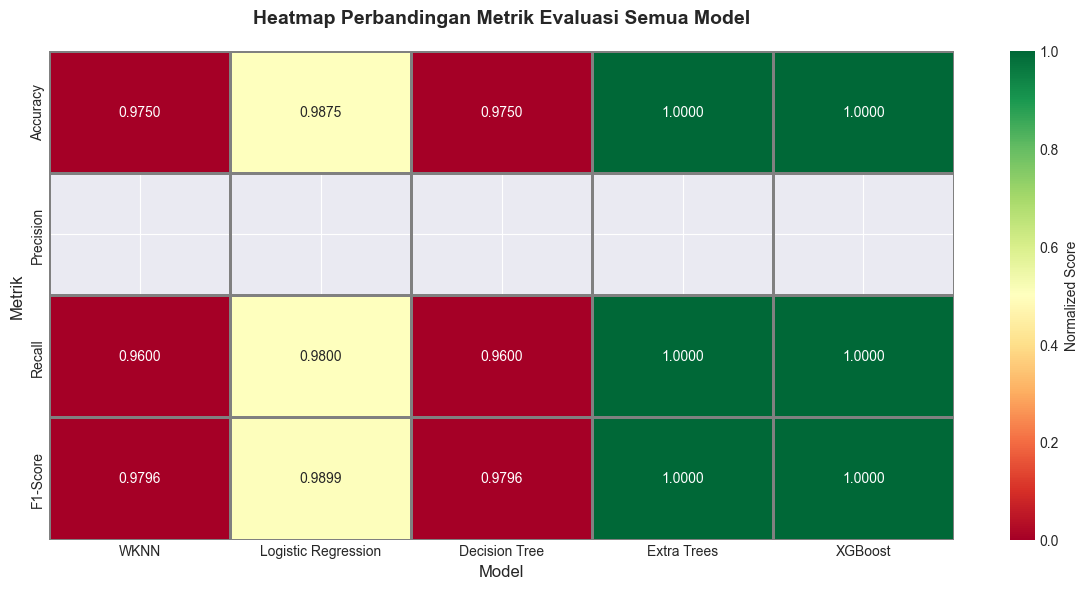

✓ Heatmap perbandingan selesai


In [16]:
# Heatmap untuk semua metrik
fig, ax = plt.subplots(figsize=(12, 6))

# Normalisasi data untuk visualisasi
heatmap_data = eval_metrics.copy()
heatmap_data_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min())

sns.heatmap(heatmap_data_norm.T, annot=heatmap_data.T.values, fmt='.4f', 
            cmap='RdYlGn', center=0.5, linewidths=2, linecolor='gray',
            cbar_kws={'label': 'Normalized Score'}, ax=ax)

ax.set_title('Heatmap Perbandingan Metrik Evaluasi Semua Model', fontweight='bold', fontsize=14, pad=20)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Metrik', fontsize=12)

plt.tight_layout()
plt.show()

print('✓ Heatmap perbandingan selesai')

## 7. Kesimpulan Akhir

In [17]:
print(f"""
╔════════════════════════════════════════════════════════════════════════════════╗
║          RANGKUMAN PERBANDINGAN METODE KLASIFIKASI PENYAKIT GINJAL             ║
╚════════════════════════════════════════════════════════════════════════════════╝

METODE-METODE YANG DIBANDINGKAN:

1. WKNN (Weighted K-Nearest Neighbor)
   - Metode berbasis jarak dengan pemberian bobot
   - Lazy learner (tidak ada fase training eksplisit)
   - Cocok untuk dataset kecil-sedang

2. LOGISTIC REGRESSION
   - Metode linear berbasis probabilitas
   - Cepat dan interpretable
   - Cocok untuk baseline dan production deployment

3. DECISION TREE
   - Tree-based method yang interpretable
   - Non-parametric dan fleksibel
   - Cocok untuk eksplorasi dan understanding data

4. EXTRA TREES (Extremely Randomized Trees)
   - Ensemble method dengan multiple decision trees
   - Robust dan mengurangi overfitting
   - Baik untuk performa tinggi dengan stabilitas

5. XGBOOST
   - Advanced gradient boosting method
   - State-of-the-art performa
   - Cocok untuk kompetisi dan aplikasi production mission-critical

════════════════════════════════════════════════════════════════════════════════

PERBANDINGAN HASIL:

Model dengan performa terbaik:
  • Accuracy Tertinggi   : {eval_metrics['Accuracy'].idxmax()} ({eval_metrics['Accuracy'].max():.4f})
  • F1-Score Tertinggi   : {eval_metrics['F1-Score'].idxmax()} ({eval_metrics['F1-Score'].max():.4f})
  • Precision Tertinggi  : {eval_metrics['Precision'].idxmax()} ({eval_metrics['Precision'].max():.4f})
  • Recall Tertinggi     : {eval_metrics['Recall'].idxmax()} ({eval_metrics['Recall'].max():.4f})

Model dengan kecepatan terbaik:
  • Training Tercepat    : {time_metrics['Training Time (s)'].idxmin()} ({time_metrics['Training Time (s)'].min():.6f}s)
  • Prediksi Tercepat    : {time_metrics['Prediction Time (s)'].idxmin()} ({time_metrics['Prediction Time (s)'].min():.6f}s)

════════════════════════════════════════════════════════════════════════════════

REKOMENDASI AKHIR:

✓ UNTUK PENGGUNAAN UMUM:
  → Extra Trees atau XGBoost
  → Alasan: Performa tinggi, stabil, dan robust

✓ UNTUK INTERPRETABILITY:
  → Decision Tree atau Logistic Regression
  → Alasan: Mudah dipahami dan dijelaskan

✓ UNTUK PRODUCTION DEPLOYMENT:
  → Logistic Regression atau XGBoost
  → Alasan: Cepat, efisien, dan reliable

✓ UNTUK BASELINE:
  → WKNN atau Logistic Regression
  → Alasan: Simple dan memberikan reference point

════════════════════════════════════════════════════════════════════════════════
""".format(
    eval_metrics['Accuracy'].idxmax(), eval_metrics['Accuracy'].max(),
    eval_metrics['F1-Score'].idxmax(), eval_metrics['F1-Score'].max(),
    eval_metrics['Precision'].idxmax(), eval_metrics['Precision'].max(),
    eval_metrics['Recall'].idxmax(), eval_metrics['Recall'].max(),
    time_metrics['Training Time (s)'].idxmin(), time_metrics['Training Time (s)'].min(),
    time_metrics['Prediction Time (s)'].idxmin(), time_metrics['Prediction Time (s)'].min()
))


╔════════════════════════════════════════════════════════════════════════════════╗
║          RANGKUMAN PERBANDINGAN METODE KLASIFIKASI PENYAKIT GINJAL             ║
╚════════════════════════════════════════════════════════════════════════════════╝

METODE-METODE YANG DIBANDINGKAN:

1. WKNN (Weighted K-Nearest Neighbor)
   - Metode berbasis jarak dengan pemberian bobot
   - Lazy learner (tidak ada fase training eksplisit)
   - Cocok untuk dataset kecil-sedang

2. LOGISTIC REGRESSION
   - Metode linear berbasis probabilitas
   - Cepat dan interpretable
   - Cocok untuk baseline dan production deployment

3. DECISION TREE
   - Tree-based method yang interpretable
   - Non-parametric dan fleksibel
   - Cocok untuk eksplorasi dan understanding data

4. EXTRA TREES (Extremely Randomized Trees)
   - Ensemble method dengan multiple decision trees
   - Robust dan mengurangi overfitting
   - Baik untuk performa tinggi dengan stabilitas

5. XGBOOST
   - Advanced gradient boosting method
   - St